# 001 - Baseline modeling dataset (short-horizon prediction)\n
\n
Цель: построить modeling dataset из реконструированного order book на сетке 100ms.\n
\n
Ноутбук — тонкий оркестратор:\n
- загрузка parquet за заданный период\n
- sanity checks (валидация состояний)\n
- сбор features + multi-horizon targets через модули\n
- сохранение dataset parquet и metadata\n
\n
Важно: вся вычислительная логика вынесена в Python-модули под `research/`, а не в монолитные ячейки.

## Leakage safeguards\n
\n
Правило: **в feature set попадают только значения, доступные на момент наблюдения t**.\n
- history-вычисления — это только `shift(+)` и rolling на прошлом (без будущего)\n
- labels-вычисления — это только будущие значения (через shift(-k) / aligned horizons)\n
- перед обучением мы drop-производим строки с NaN в target-колонках\n
\n
Для горизонтов 150/250ms и т.п. используется policy: **первое наблюдение на сетке, которое попадает в t + H (ceil до ближайшей grid-точки)**.\n
Это явно отражается в metadata.

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd

# Root detection
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]
root = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from research.utils.reconstructed_parquet_loader import load_reconstructed_grid_parquet
from research.utils.dataset_assembly import ModelingDatasetConfig, build_modeling_dataset
from research.labels.profitability_targets import MakerTakerFeeModel

print("root:", root)

root: d:\tumar\okx-hft-research


In [2]:
# =============================
# CONFIG
# =============================
INST_ID = "BTC-USDT-SWAP"
START = "2026-03-23 00:00:00"
END = "2026-03-25 23:59:59"

# Dataset building parameters
GRID_MS = 100
DEPTH_K = 10

HORIZONS_MS = [100, 150, 200, 250, 500, 1000]
TICK_THRESHOLDS = (1, 2, 3)
LOOKBACK_MS = (100, 200, 500, 1000)

# Profitability-aware proxy
FEE_MODEL = MakerTakerFeeModel(
    maker_fee_rate=0.0002,  # пример: 2 bps
    taker_fee_rate=0.0007,  # пример: 7 bps
    min_profit_ticks=0.0,
)
GROSS_PROFIT_MIN_TICKS = 1.0

# TP/SL labeling
TAKE_PROFIT_TICKS = (1, 2, 3)
STOP_LOSS_TICKS = (1, 2)
HOLDING_MS = (100, 250, 500, 1000)

# Tick size: infer from data by default (safer than hardcoding)
TICK_SIZE = None  # или float, например 0.1

OUTPUT_DIR = root / "data" / "processed" / "modeling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("INST_ID:", INST_ID)
print("Window:", START, "..", END)

INST_ID: BTC-USDT-SWAP
Window: 2026-03-23 00:00:00 .. 2026-03-25 23:59:59


In [3]:
start_ts = pd.Timestamp(START, tz="UTC")
end_ts = pd.Timestamp(END, tz="UTC")
base_dir = root / "data" / "reconstructed"

load_res = load_reconstructed_grid_parquet(
    base_dir=base_dir,
    inst_id=INST_ID,
    start_ts=start_ts,
    end_ts=end_ts,
    grid_dirname="grid100ms",
)
df = load_res.df

print("Loaded rows:", len(df))
print("Selected parquet files:", len(load_res.selected_files))
df.head()

Loaded rows: 2592062
Selected parquet files: 72


,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-23 00:00:00+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,456.44,67830.7,0.43,...,67831.6,0.75,67831.7,13.78,67831.8,0.02,67831.9,70.47,67832.1,0.05
1,2026-03-23 00:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,466.58,67830.7,0.43,...,67831.8,0.03,67831.9,70.47,67832.1,0.05,67832.2,0.06,67832.3,22.34
2,2026-03-23 00:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,488.05,67830.7,0.43,...,67831.9,0.05,67832.1,0.05,67832.2,0.05,67832.3,0.06,67832.4,0.03
3,2026-03-23 00:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67840.65,0.1,67840.6,1032.91,67840.5,8.02,...,67842.1,0.03,67842.2,0.01,67842.7,0.04,67842.8,0.90,67843.1,0.01
4,2026-03-23 00:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67843.85,0.1,67843.8,914.75,67843.7,0.01,...,67844.6,0.01,67845.1,0.03,67845.3,0.01,67845.4,0.33,67845.6,0.01


In [4]:
# =============================
# Sanity checks (no leakage)
# =============================
work = df.copy()
work["ts_event"] = pd.to_datetime(work["ts_event"], utc=True, errors="coerce")
work = work.dropna(subset=["ts_event"]).sort_values("ts_event").reset_index(drop=True)

quality = {}
quality["rows_before"] = len(work)
quality["duplicate_ts_rows"] = int(work.duplicated(subset=["ts_event"]).sum())

# negative/zero sizes
bid_sz_cols = [f"bid_sz_{i:02d}" for i in range(1, DEPTH_K + 1)]
ask_sz_cols = [f"ask_sz_{i:02d}" for i in range(1, DEPTH_K + 1)]
quality["negative_or_zero_sizes_total"] = int(((work[bid_sz_cols + ask_sz_cols] <= 0).sum().sum()))

# crossed book
quality["crossed_book_rows"] = int(((work["bid_px_01"] >= work["ask_px_01"]).fillna(False)).sum())

# filter invalid rows
mask_valid = (
    (work[bid_sz_cols + ask_sz_cols] > 0).all(axis=1)
    & (work["bid_px_01"] < work["ask_px_01"])
)
work = work.loc[mask_valid].copy()

quality["rows_after"] = len(work)

print("Quality report:\n", json.dumps(quality, indent=2, default=str))
work.head()

Quality report:
 {
  "rows_before": 2592062,
  "duplicate_ts_rows": 71,
  "negative_or_zero_sizes_total": 0,
  "crossed_book_rows": 0,
  "rows_after": 2592062
}


,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-23 00:00:00+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,456.44,67830.7,0.43,...,67831.6,0.75,67831.7,13.78,67831.8,0.02,67831.9,70.47,67832.1,0.05
1,2026-03-23 00:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,466.58,67830.7,0.43,...,67831.8,0.03,67831.9,70.47,67832.1,0.05,67832.2,0.06,67832.3,22.34
2,2026-03-23 00:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67830.85,0.1,67830.8,488.05,67830.7,0.43,...,67831.9,0.05,67832.1,0.05,67832.2,0.05,67832.3,0.06,67832.4,0.03
3,2026-03-23 00:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67840.65,0.1,67840.6,1032.91,67840.5,8.02,...,67842.1,0.03,67842.2,0.01,67842.7,0.04,67842.8,0.90,67843.1,0.01
4,2026-03-23 00:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,67843.85,0.1,67843.8,914.75,67843.7,0.01,...,67844.6,0.01,67845.1,0.03,67845.3,0.01,67845.4,0.33,67845.6,0.01


In [5]:
# =============================
# Build dataset (features + labels)
# =============================
config = ModelingDatasetConfig(
    grid_ms=GRID_MS,
    depth_k=DEPTH_K,
    horizons_ms=tuple(HORIZONS_MS),
    tick_thresholds=TICK_THRESHOLDS,
    lookback_ms=LOOKBACK_MS,
    gross_profit_min_ticks=float(GROSS_PROFIT_MIN_TICKS),
    fee_model=FEE_MODEL,
    take_profit_ticks=TAKE_PROFIT_TICKS,
    stop_loss_ticks=STOP_LOSS_TICKS,
    holding_ms=HOLDING_MS,
    tick_size=TICK_SIZE,
)

dataset_df, metadata = build_modeling_dataset(work, config=config, ts_col="ts_event")

print("Dataset rows:", len(dataset_df))
print("Feature+target cols:", len(dataset_df.columns))
dataset_df.head()

d:\tumar\okx-hft-research\research\features\orderbook_baseline_features.py:157: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"spread_change_ticks_{tag}"] = out[f"spread_change_{tag}"] / tick_size
d:\tumar\okx-hft-research\research\features\orderbook_baseline_features.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"imbalance_top1_change_{tag}"] = out["imbalance_top1"].shift(0) - out["imbalance_top1"].shift(steps)
d:\tumar\okx-hft-research\research\features\orderbook_baseline_features.py:161: PerformanceWarning: 

Dataset rows: 2592052
Feature+target cols: 254


,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,tick_size,best_bid_px,best_ask_px,best_bid_sz,best_ask_sz,mid_px,...,label_tp2_sl2_hold500_short,label_tp2_sl2_hold1000_short,label_tp3_sl1_hold100_short,label_tp3_sl1_hold250_short,label_tp3_sl1_hold500_short,label_tp3_sl1_hold1000_short,label_tp3_sl2_hold100_short,label_tp3_sl2_hold250_short,label_tp3_sl2_hold500_short,label_tp3_sl2_hold1000_short
0,2026-03-23 00:00:00+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,0.1,67830.8,67830.9,456.44,1006.90,67830.85,...,-1,-1,0,-1,-1,-1,0,-1,-1,-1
1,2026-03-23 00:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,0.1,67830.8,67830.9,466.58,934.90,67830.85,...,-1,-1,0,-1,-1,-1,0,-1,-1,-1
2,2026-03-23 00:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,0.1,67830.8,67830.9,488.05,3.03,67830.85,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,2026-03-23 00:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,0.1,67840.6,67840.7,1032.91,198.08,67840.65,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,2026-03-23 00:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-22 23:59:47.104000+00:00,grid_100ms,0.1,67843.8,67843.9,914.75,458.60,67843.85,...,0,-1,0,0,0,-1,0,0,0,-1


In [6]:
# =============================
# Target/feature lists + class balance
# =============================
target_cols = [
    c
    for c in dataset_df.columns
    if c.startswith("target_")
    or c.startswith("label_")
    or c.startswith("mid_move_ticks_")
    or c.startswith("best_bid_move_ticks_")
    or c.startswith("best_ask_move_ticks_")
]
feature_cols = [c for c in dataset_df.columns if c not in set(target_cols)]

print("#feature cols:", len(feature_cols))
print("#target cols:", len(target_cols))
metadata["targets"]

# Class balance for binary targets (skip {-1,0,1} labels)
binary_targets = [c for c in target_cols if dataset_df[c].dropna().unique().size <= 2 and dataset_df[c].dropna().dtype != object]

bal_rows = []
for c in binary_targets:
    s = dataset_df[c].value_counts(normalize=True)
    bal_rows.append({"target": c, "p1": float(s.get(1, 0.0)), "p0": float(s.get(0, 0.0))})

bal_df = pd.DataFrame(bal_rows).sort_values("target")
display(bal_df.head(30))
print("Binary targets total:", len(bal_df))

#feature cols: 110
#target cols: 144


,target,p1,p0
38,target_gross_profitable_h100,0.697131,0.302869
68,target_gross_profitable_h1000,0.802573,0.197427
44,target_gross_profitable_h150,0.715128,0.284872
50,target_gross_profitable_h200,0.715128,0.284872
56,target_gross_profitable_h250,0.730406,0.269594
62,target_gross_profitable_h500,0.755974,0.244026
36,target_gross_profitable_long_h100,0.658490,0.341510
66,target_gross_profitable_long_h1000,0.605842,0.394158
42,target_gross_profitable_long_h150,0.649886,0.350114
48,target_gross_profitable_long_h200,0.649886,0.350114


Binary targets total: 72


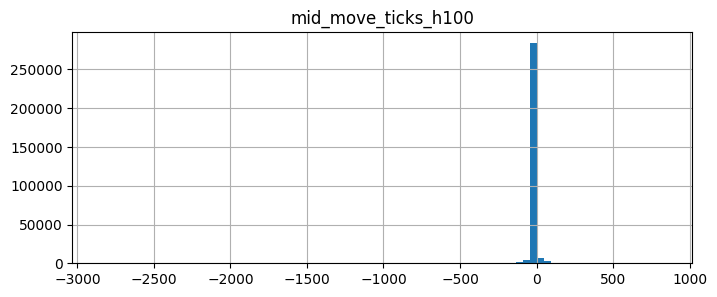

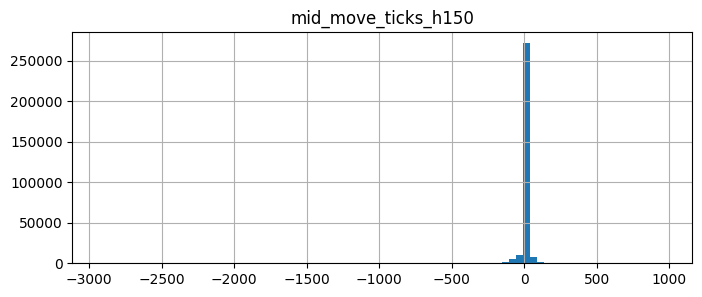

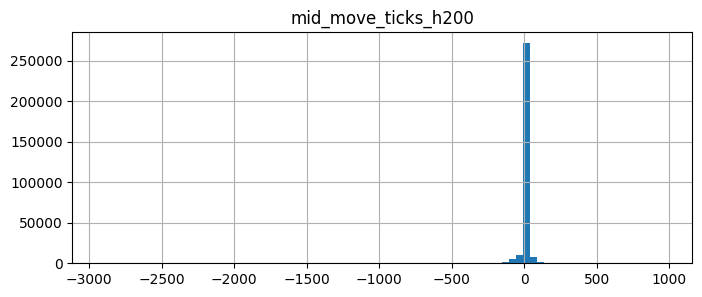

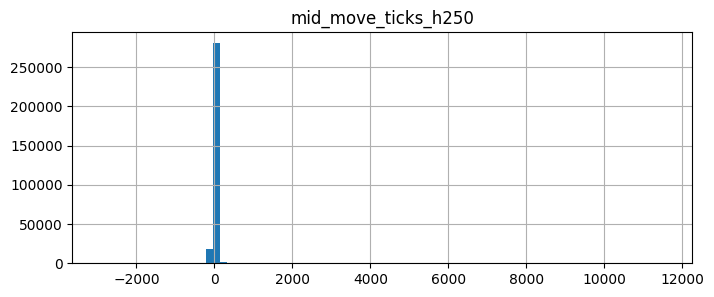

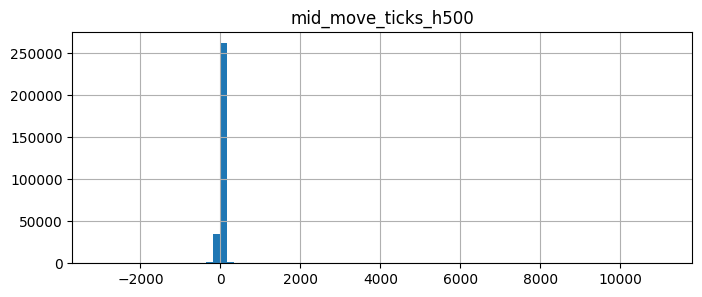

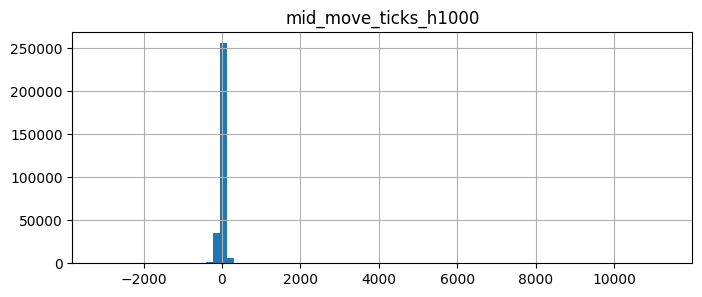

Done sanity plots.


In [7]:
# =============================
# Sanity plots on samples
# =============================
sample = dataset_df
if len(sample) > 300_000:
    sample = sample.sample(300_000, random_state=42)

for h in HORIZONS_MS:
    col = f"mid_move_ticks_h{h}"
    if col in sample.columns:
        ax = sample[col].hist(bins=80, figsize=(8, 3))
        ax = ax
        import matplotlib.pyplot as plt
        plt.title(col)
        plt.show()

print("Done sanity plots.")

In [8]:
# =============================
# Save dataset + metadata
# =============================
run_tag = f"{pd.Timestamp(START).strftime('%Y%m%d_%H%M%S')}__{pd.Timestamp(END).strftime('%Y%m%d_%H%M%S')}" 
out_parquet = OUTPUT_DIR / f"{INST_ID.lower().replace('-', '_')}_model_dataset_{GRID_MS}ms_baseline_{run_tag}.parquet"
out_meta = OUTPUT_DIR / f"{INST_ID.lower().replace('-', '_')}_model_dataset_{GRID_MS}ms_baseline_{run_tag}_metadata.json"

dataset_df.to_parquet(out_parquet, index=False)

metadata["feature_cols"] = feature_cols
metadata["target_cols"] = target_cols
metadata["quality"] = quality
metadata["output_parquet"] = str(out_parquet)
metadata["output_metadata"] = str(out_meta)

out_meta.write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

print("Saved:")
print(out_parquet)
print(out_meta)

Saved:
d:\tumar\okx-hft-research\data\processed\modeling\btc_usdt_swap_model_dataset_100ms_baseline_20260323_000000__20260325_235959.parquet
d:\tumar\okx-hft-research\data\processed\modeling\btc_usdt_swap_model_dataset_100ms_baseline_20260323_000000__20260325_235959_metadata.json


## Что считать готовым для следующего шага

- Dataset parquet сохранён в `data/processed/modeling/`
- В metadata есть tick size, aligned horizon policy и список `feature_cols` / `target_cols`
- Наличие target families:
  - raw directional (на mid)
  - tick-threshold binary directionality
  - gross/net profitability (maker-taker proxy)
  - TP/SL ordering label

Следующий шаг — обучить baseline model и использовать metadata для воспроизводимости.

## Принятые допущения (коротко)

- **Tick size**: по умолчанию инферится из `mid_px` (мода малых положительных изменений). При желании можно задать `TICK_SIZE` явно в конфиге.
- **Alignment горизонтов**: для `h=150/250ms` и т.п. на сетке 100ms используется policy **ceil-to-next-grid**: метка считается по первому доступному наблюдению, которое попадает в `t + H` (на регулярной сетке это соответствует шагам `ceil(H / grid_ms)`).
- **Profitability proxy (maker-taker)**:
  - Long: entry `best_bid_px_01(t)`, exit `best_ask_px_01(t+H)`.
  - Short: entry `best_ask_px_01(t)`, exit `best_bid_px_01(t+H)`.
  - Net profitability учитывает maker/taker fees как доли notional, плюс `min_profit_ticks`.
- **TP/SL labeling**:
  - TP/SL проверяется на **mid_px** относительно цены entry.
  - Long entry: `best_bid_px_01(t)`; TP — mid вверх на `TP*tick_size`, SL — mid вниз на `SL*tick_size`.
  - Short entry: `best_ask_px_01(t)`; TP — mid вниз на `TP*tick_size`, SL — mid вверх на `SL*tick_size`.


In [14]:
for i in dataset_df.columns:
    print(i)

ts_event
inst_id
anchor_snapshot_ts
reconstruction_mode
tick_size
best_bid_px
best_ask_px
best_bid_sz
best_ask_sz
mid_px
spread_px
mid_to_best_bid_ticks
best_ask_to_mid_ticks
relative_spread
spread_bps
bid_vol_top1
ask_vol_top1
bid_vol_top3
ask_vol_top3
bid_vol_top5
ask_vol_top5
bid_vol_top10
ask_vol_top10
imbalance_top1
imbalance_top3
imbalance_top5
imbalance_top10
microprice
microprice_minus_mid_ticks
bid_level_01_dist_ticks
ask_level_01_dist_ticks
bid_level_02_dist_ticks
ask_level_02_dist_ticks
bid_level_03_dist_ticks
ask_level_03_dist_ticks
bid_level_04_dist_ticks
ask_level_04_dist_ticks
bid_level_05_dist_ticks
ask_level_05_dist_ticks
bid_level_06_dist_ticks
ask_level_06_dist_ticks
bid_level_07_dist_ticks
ask_level_07_dist_ticks
bid_level_08_dist_ticks
ask_level_08_dist_ticks
bid_level_09_dist_ticks
ask_level_09_dist_ticks
bid_level_10_dist_ticks
ask_level_10_dist_ticks
cum_bid_sz_01
cum_ask_sz_01
cum_bid_sz_02
cum_ask_sz_02
cum_bid_sz_03
cum_ask_sz_03
cum_bid_sz_04
cum_ask_sz_04
c